In [18]:
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Génération du dataset ──────────────────────────────────────────────────
np.random.seed(0)  # To ensure reproducibility
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

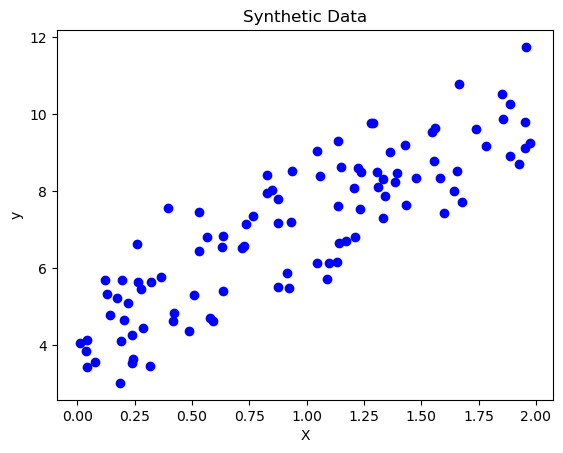

In [20]:
# ── 2. Affichage du dataset ───────────────────────────────────────────────────
# Plotting the data
plt.scatter(X, y, color='blue')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Synthetic Data")
plt.show()

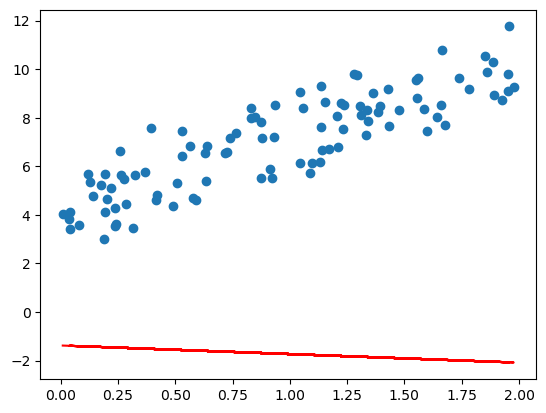

In [25]:
# ── 3. Modèle linéaire : prédiction  (y_pred = wX + b) ───────────────────────
def predict(X, w, b):
    return (X.dot(w) + b).reshape(X.shape[0], 1)

# Tracé de la première droite aléatoire
w, b = np.random.randn(2, 1)
plt.scatter(X, y)
plt.plot(X, predict(X, w, b), c='r')
plt.show()

In [26]:
# ── 4. Fonction coût : MSE ────────────────────────────────────────────────────
# J(θ) = (1 / 2m) * Σ(y_pred - y)²
def compute_cost(X, y, w, b):
    y_pred = predict(X, w, b)
    cost = (1 / (2 * len(y))) * np.sum((y_pred - y) ** 2)
    return cost


In [27]:
# ── 5. Calcul des gradients ───────────────────────────────────────────────────
# dJ/dw = (1/m) * Σ(y_pred - y) * x
# dJ/db = (1/m) * Σ(y_pred - y)
def compute_gradients(x, y, w, b):
    m = len(y)
    y_pred = w * x + b
    dw = (1 / m) * np.sum((y_pred - y) * x)
    db = (1 / m) * np.sum(y_pred - y)
    return dw, db

In [28]:
def gradient_descent(x, y, w, b, learning_rate, n_iterations):
    cost_history = []  # pour stocker l'historique du coût

    for i in range(n_iterations):
        # Calcul des gradients
        dw, db = compute_gradients(x, y, w, b)

        # Mise à jour des paramètres
        w = w - learning_rate * dw
        b = b - learning_rate * db

        # Calcul et enregistrement du coût
        cost = compute_cost(x, y, w, b)
        cost_history.append(cost)

        # Affichage du coût toutes les 100 itérations
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost}")

    return w, b, cost_history


In [29]:
# ── 7. Phase d'entraînement ───────────────────────────────────────────────────
# Initialize parameters
w = np.random.randn(1)
b = np.random.randn(1)
learning_rate = 0.01
n_iterations = 1000

# Run gradient descent
w, b, cost_history = gradient_descent(X, y, w, b, learning_rate, n_iterations)

Iteration 0: Cost = 49.226959460010534
Iteration 100: Cost = 1.5800012447902054
Iteration 200: Cost = 0.7550591098770457
Iteration 300: Cost = 0.6756717852493873
Iteration 400: Cost = 0.6261224155992146
Iteration 500: Cost = 0.5903425777909567
Iteration 600: Cost = 0.5644191127732515
Iteration 700: Cost = 0.5456355200101429
Iteration 800: Cost = 0.5320253066259962
Iteration 900: Cost = 0.5221636195332404


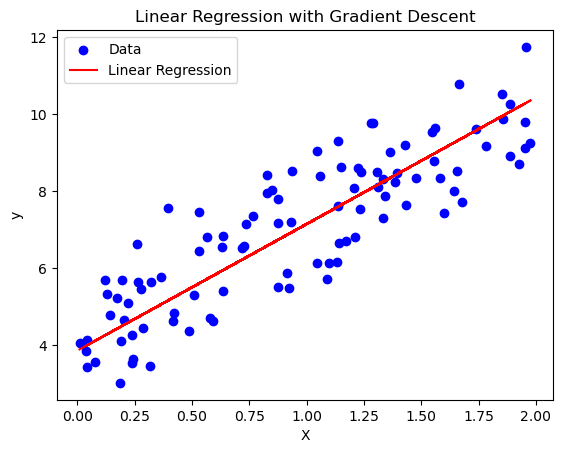

In [30]:
# ── 8. Visualisation des résultats ───────────────────────────────────────────
# Final predictions
y_pred = predict(X, w, b)

# Plot regression line
plt.scatter(X, y, color='blue', label="Data")       # Scatter plot for the data
plt.plot(X, y_pred, color='red', label="Linear Regression")  # Regression line
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.title("Linear Regression with Gradient Descent")
plt.show()

dimension de X: (1797, 64)
dimension de Y: (1797,)


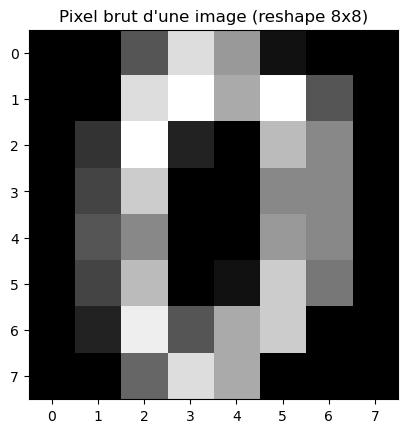

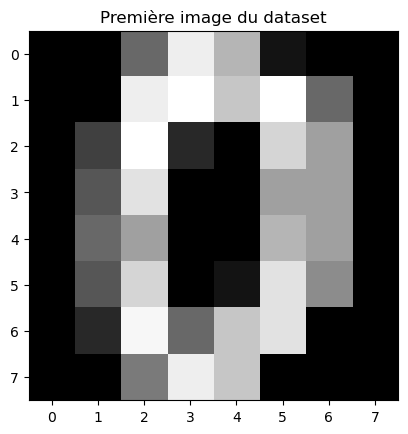

In [38]:
# ============================================================
#  APPLICATION : Vision par ordinateur avec K-NN
#  Reconnaissance de chiffres manuscrits (0 à 9)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.neighbors import KNeighborsClassifier


# ── 1. Chargement du dataset ──────────────────────────────────
# load_digits() charge un dataset de 1797 images de chiffres
# manuscrits (0 à 9). Chaque image est de taille 8x8 pixels,
# soit 64 valeurs (features) par image.
digits = load_digits()

X = digits.data    # Matrice des features : shape (1797, 64)
y = digits.target  # Labels (chiffres réels) : shape (1797,)

print('dimension de X:', X.shape)   # (1797, 64)
print('dimension de Y:', y.shape)   # (1797,)


# ── 2. Affichage d'un pixel brut (vecteur de 64 valeurs) ─────
# Chaque image est stockée comme un vecteur de 64 pixels.
# reshape(8,8) reconstruit la grille 8×8 pour l'afficher.
plt.imshow(
    np.array([ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.,
               0.,  0., 13., 15., 10., 15.,  5.,  0.,
               0.,  3., 15.,  2.,  0., 11.,  8.,  0.,
               0.,  4., 12.,  0.,  0.,  8.,  8.,  0.,
               0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.,
               0.,  4., 11.,  0.,  1., 12.,  7.,  0.,
               0.,  2., 14.,  5., 10., 12.,  0.,  0.,
               0.,  0.,  6., 13., 10.,  0.,  0.,  0.]).reshape(8, 8),
    cmap="gray"
)
plt.title("Pixel brut d'une image (reshape 8x8)")
plt.show()


# ── 3. Visualisation d'une seule image du dataset ────────────
# digits['images'] contient les images déjà en forme 8x8.
# On affiche la première image (index 0).
plt.imshow(digits['images'][0], cmap='Greys_r')
plt.title("Première image du dataset")
plt.show()




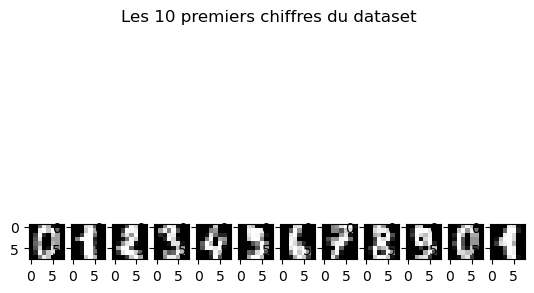

In [41]:
# ── 4. Visualisation des 10 premiers chiffres ────────────────
# On affiche les 10 premières images côte à côte
# pour avoir un aperçu des données.
for i in range(12):
    plt.subplot(1, 12, i + 1)                          # 1 ligne, 10 colonnes
    plt.imshow(digits['images'][i], cmap='Greys_r')    # Affiche image i
plt.suptitle("Les 10 premiers chiffres du dataset")
plt.show()




Valeur de k choisie (k = √n) : 42
Score du modèle : 0.9655


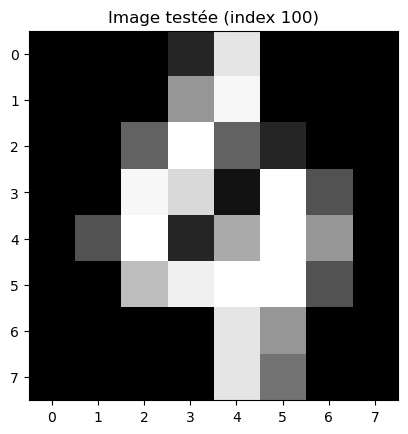


Chiffre prédit par le modèle : 4
Chiffre réel                 : 4


In [ ]:

# ── 5. Entraînement du modèle K-NN ───────────────────────────
k = int(np.sqrt(len(y)))   # k = √1797 ≈ 42
print(f"\nValeur de k choisie (k = √n) : {k}")

model = KNeighborsClassifier(n_neighbors=k)
model.fit(X, y)            # Entraînement sur tout le dataset

# Score de précision sur les données d'entraînement
score = model.score(X, y)
print(f"Score du modèle : {score:.4f}")   # ~0.9905


# ── 6. Test du modèle sur une nouvelle image ─────────────────
# On prend l'image à l'index 100 comme exemple de test.
# reshape(1, -1) : transforme le vecteur en ligne (1 exemple)
# pour que predict() puisse le traiter.
test = digits['images'][100].reshape(1, -1)

# Affichage de l'image testée
plt.imshow(digits['images'][100], cmap='Greys_r')
plt.title("Image testée (index 100)")
plt.show()

# Prédiction : le modèle retourne le chiffre reconnu
prediction = model.predict(test)
print(f"\nChiffre prédit par le modèle : {prediction[0]}")
print(f"Chiffre réel                 : {y[100]}")